# SHAP Performance Regimes
This notebook assembles a run-scoped regime analysis table for one XGBoost interpretable-model run, evaluates reduced SHAP representations, compares clustering behavior across performance groups, and inspects the selected cluster SHAP signatures for easy, medium, and hard trajectory outcomes.


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from data_modelling.prepared_data import load_prepared_data, prepare_single_target_model_data
from data_modelling.run_context import format_exported_model_label, get_exported_model_info, load_run_context
from data_modelling.shap_performance_regimes_utils import (
    assemble_step1_analysis_table,
    build_cluster_shap_profiles,
    evaluate_umap_trustworthiness_by_group,
    format_shap_feature_name,
    get_shap_cols,
    resolve_raw_metric_col,
    run_step2_clustering,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

MODEL_ID = 'xgboost'
RUN_NAME = "nusc_mini_debug_tpp-11_Mar_2026_15_29_02"
EVAL_CSV_NAME = "eval_epoch_5.csv"
TARGET_COL = None  # Optional override, e.g. 'ml_ade_log'
LOWER_IS_BETTER = True
PERFORMANCE_GROUP_COL = 'performance_group'

CLUSTER_SPEC = {
    'groups': ['easy', 'medium', 'hard'],
    'algorithms': ['hdbscan', 'optics'],
    'evaluate_umap_latent_space': True,
    # The notebook resolves candidate dimensions to 1..(#features - 1) after the SHAP columns are loaded.
    'umap_candidate_dims': None,
    # Set one integer for all groups or a dict like {'easy': 2, 'medium': 4, 'hard': 2} after inspecting the trustworthiness plot.
    'umap_selected_n_components': {'easy': 3, 'medium': 3, 'hard': 3},
    'trustworthiness_neighbor_values': [5, 10, 15],
    'cluster_umap_n_neighbors': 30,
    'cluster_umap_min_dist': 0.0,
    'viz_umap_n_neighbors': 15,
    'viz_umap_min_dist': 0.1,
    'random_state': 42,
    # Set one integer for all groups or a dict like {'easy': 6, 'medium': 12, 'hard': 6}.
    'min_cluster_size': 5,
    # Set one integer for all groups or a dict like {'easy': 6, 'medium': 12, 'hard': 6}.
    'min_samples': 5,
    'optics_cluster_method': 'xi',
    'optics_xi': 0.05,
    'distance_metric': 'euclidean',
}

INSPECTION_CONFIG = {
    'inspection_algorithm': 'hdbscan',
    'inspection_cluster_space': 'umap',
    'inspection_top_k_features': 8,
    'inspection_top_k_table': 3,
    'sort_cluster_profiles_by': 'cluster_size',
}

if MODEL_ID != 'xgboost':
    raise NotImplementedError("This notebook currently supports MODEL_ID='xgboost' only.")



## Resolve Run Context and Artifact Paths
**Purpose:** Tie every input and output to one exported modelling run and one joined-metrics file.<br>
**Inputs:** `RUN_NAME`, `EVAL_CSV_NAME`, `MODEL_ID`, optional `TARGET_COL`.


In [2]:
run_ctx = load_run_context(MODEL_ID, RUN_NAME, TARGET_COL)
manifest = run_ctx.manifest
target_col = run_ctx.target_col
feature_cols = run_ctx.feature_cols
exported_model_info = get_exported_model_info(manifest)
exported_model_label = format_exported_model_label(exported_model_info)
raw_metric_col = resolve_raw_metric_col(manifest, target_col)

PREPARED_DATA_PATH = Path('../../results/interpretable_model/prepared_data') / RUN_NAME / f'prepared_data_{raw_metric_col}.csv'
SHAP_VALUES_PATH = run_ctx.tables_dir / f'shap_values_{target_col}.csv'
JOINED_METRICS_PATH = Path('../../results/trajectory_prediction/trajectory_metrics_joined') / RUN_NAME / EVAL_CSV_NAME
RESULTS_ROOT = Path('../../results/interpretable_model/shap_performance_regimes') / RUN_NAME
TABLES_DIR = RESULTS_ROOT / 'tables'
PLOTS_DIR = RESULTS_ROOT / 'plots'
TABLES_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

REGIME_ANALYSIS_PATH = TABLES_DIR / f'regime_analysis_{target_col}.csv'
PERFORMANCE_GROUP_SUMMARY_PATH = TABLES_DIR / f'performance_group_summary_{target_col}.csv'
UMAP_TRUSTWORTHINESS_PATH = TABLES_DIR / f'umap_trustworthiness_{target_col}.csv'
CLUSTER_SCORES_PATH = TABLES_DIR / f'cluster_scores_{target_col}.csv'
CLUSTER_ASSIGNMENTS_PATH = TABLES_DIR / f'cluster_assignments_{target_col}.csv'
CLUSTER_SHAP_PROFILES_PATH = TABLES_DIR / f'cluster_shap_profiles_{target_col}.csv'
UMAP_TRUSTWORTHINESS_PLOT_PATHS = {
    'nn_5': PLOTS_DIR / f'umap_trustworthiness_curve_nn5_{target_col}.png',
    'nn_10': PLOTS_DIR / f'umap_trustworthiness_curve_nn10_{target_col}.png',
    'nn_15': PLOTS_DIR / f'umap_trustworthiness_curve_nn15_{target_col}.png',
    'mean_5_10_15': PLOTS_DIR / f'umap_trustworthiness_curve_mean_{target_col}.png',
}
RAW_ALGORITHM_GRID_PATH = PLOTS_DIR / f'raw_algorithm_comparison_grid_{target_col}.png'
UMAP_ALGORITHM_GRID_PATH = PLOTS_DIR / f'umap_algorithm_comparison_grid_{target_col}.png'

required_paths = [
    ('prepared data export', PREPARED_DATA_PATH),
    ('SHAP value export', SHAP_VALUES_PATH),
    ('joined metrics export', JOINED_METRICS_PATH),
]
for label, path in required_paths:
    if not path.exists():
        raise FileNotFoundError(f'Missing required {label}: {path}')

print(f'Run: {RUN_NAME}')
print(f'Eval CSV: {EVAL_CSV_NAME}')
print(f'Exported model: {exported_model_label}')
print(f'Resolved target_col: {target_col}')
print(f'Resolved raw metric col: {raw_metric_col}')
print(f'Feature count: {len(feature_cols)}')
print(f'Prepared data path: {PREPARED_DATA_PATH}')
print(f'SHAP values path: {SHAP_VALUES_PATH}')
print(f'Joined metrics path: {JOINED_METRICS_PATH}')
print(f'Results root: {RESULTS_ROOT.resolve()}')



Run: nusc_mini_debug_tpp-11_Mar_2026_15_29_02
Eval CSV: eval_epoch_5.csv
Exported model: XGBoost (xgboost, target_mode=log)
Resolved target_col: ml_ade_log
Resolved raw metric col: ml_ade
Feature count: 13
Prepared data path: ../../results/interpretable_model/prepared_data/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/prepared_data_ml_ade.csv
SHAP values path: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/xgboost/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/shap_values_ml_ade_log.csv
Joined metrics path: ../../results/trajectory_prediction/trajectory_metrics_joined/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/eval_epoch_5.csv
Results root: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/shap_performance_regimes/nusc_mini_debug_tpp-11_Mar_2026_15_29_02


## Load the Prepared Modelling Table
**Purpose:** Reconstruct the exact modelling rows and feature key used by the interpretable model.


In [3]:
prepared_df = load_prepared_data(
    PREPARED_DATA_PATH,
    display_fn=display,
    include_missing_summary=True,
    include_dtype_summary=True,
)

prepared = prepare_single_target_model_data(
    prepared_df,
    target_col=target_col,
    default_target=raw_metric_col,
)
model_df = prepared['model_df'].copy()
prepared_feature_cols = prepared['feature_cols']

if prepared['target_col'] != target_col:
    raise ValueError(f"Prepared target mismatch. expected={target_col}, actual={prepared['target_col']}")
if prepared_feature_cols != feature_cols:
    raise ValueError(
        'Prepared feature columns do not match the run manifest exactly. '
        f'expected={feature_cols}, actual={prepared_feature_cols}'
    )

print(f'Prepared modelling rows: {len(model_df)}')
print(f'Prepared feature key size: {len(prepared_feature_cols)}')


Dataset shape: (451, 14)
Columns:
['max_speed', 'std_speed', 'mean_acceleration', 'mean_jerk', 'heading_change', 'has_collision', 'min_neighbor_distance', 'scene_num_agents', 'scene_bbox_area', 'scene_bbox_width', 'scene_bbox_height', 'scene_spatial_density', 'scene_density_VEHICLE', 'ml_ade_log']


,max_speed,std_speed,mean_acceleration,mean_jerk,heading_change,has_collision,min_neighbor_distance,scene_num_agents,scene_bbox_area,scene_bbox_width,scene_bbox_height,scene_spatial_density,scene_density_VEHICLE,ml_ade_log
0,1.230403,0.116722,0.056417,0.490805,112.440745,0.0,1.013903,17.0,1160.377375,40.869190,28.392473,0.014650,0.005171,0.649643
1,0.218477,0.063105,0.007725,0.490449,941.304051,0.0,3.023524,17.0,1160.377375,40.869190,28.392473,0.014650,0.005171,0.140704
2,0.383437,0.099171,0.031384,0.401269,488.173829,0.0,1.104355,50.0,1821.083675,44.533135,40.892780,0.027456,0.012630,0.388765
3,1.483624,0.190256,0.051802,0.879107,81.155053,1.0,0.426945,16.0,1230.401053,43.391608,28.355738,0.013004,0.005689,0.821990
4,0.218477,0.064457,0.010995,0.483671,946.683531,0.0,2.796330,15.0,1057.088774,37.340273,28.309616,0.014190,0.005676,0.159340



Missing values per column:


,missing_count
max_speed,0
std_speed,0
mean_acceleration,0
mean_jerk,0
heading_change,0
has_collision,0
min_neighbor_distance,0
scene_num_agents,0
scene_bbox_area,0
scene_bbox_width,0



Column dtypes:


,dtype
max_speed,float64
std_speed,float64
mean_acceleration,float64
mean_jerk,float64
heading_change,float64
has_collision,float64
min_neighbor_distance,float64
scene_num_agents,float64
scene_bbox_area,float64
scene_bbox_width,float64


Prepared modelling rows: 451
Prepared feature key size: 13


## Assemble the Performance-Regime Table
**Purpose:** Join prepared rows, run-scoped metrics, and SHAP exports, then assign `easy` / `medium` / `hard` performance groups.


In [4]:
joined_metrics_df = pd.read_csv(JOINED_METRICS_PATH)
shap_values_df = pd.read_csv(SHAP_VALUES_PATH)

analysis_df, group_summary_df = assemble_step1_analysis_table(
    prepared_model_df=model_df,
    joined_metrics_df=joined_metrics_df,
    shap_values_df=shap_values_df,
    feature_cols=feature_cols,
    target_col=target_col,
    performance_metric_col=raw_metric_col,
    lower_is_better=LOWER_IS_BETTER,
    performance_group_col=PERFORMANCE_GROUP_COL,
)

shap_cols = get_shap_cols(analysis_df)
CLUSTER_SPEC_RESOLVED = dict(CLUSTER_SPEC)
CLUSTER_SPEC_RESOLVED['umap_candidate_dims'] = list(range(1, len(shap_cols)))

group_counts_df = (
    analysis_df[PERFORMANCE_GROUP_COL]
    .value_counts()
    .rename_axis(PERFORMANCE_GROUP_COL)
    .reset_index(name='count')
)

print(f'Joined metrics rows: {len(joined_metrics_df)}')
print(f'SHAP value rows: {len(shap_values_df)}')
print(f'Analysis rows: {len(analysis_df)}')
print(f'SHAP feature columns available: {len(shap_cols)}')
print(f"UMAP candidate dimensions: {CLUSTER_SPEC_RESOLVED['umap_candidate_dims']}")

display(group_summary_df)
display(group_counts_df)
display(analysis_df.head())


Joined metrics rows: 451
SHAP value rows: 451
Analysis rows: 451
SHAP feature columns available: 13
UMAP candidate dimensions: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


,metric_col,q25,q75,n_total,n_easy,n_medium,n_hard,n_equal_q25,n_equal_q75
0,ml_ade,0.353661,1.079434,451,113,225,113,0,0


,performance_group,count
0,medium,225
1,easy,113
2,hard,113


,max_speed,std_speed,mean_acceleration,mean_jerk,heading_change,has_collision,min_neighbor_distance,scene_num_agents,scene_bbox_area,scene_bbox_width,...,shap__has_collision,shap__min_neighbor_distance,shap__scene_num_agents,shap__scene_bbox_area,shap__scene_bbox_width,shap__scene_bbox_height,shap__scene_spatial_density,shap__scene_density_VEHICLE,shap_base_value,performance_group
0,1.230403,0.116722,0.056417,0.490805,112.440745,0.0,1.013903,17.0,1160.377375,40.869190,...,0.001430,-0.035135,0.001324,-0.026313,-0.004604,-0.005327,-0.015913,-0.000752,0.548927,medium
1,0.218477,0.063105,0.007725,0.490449,941.304051,0.0,3.023524,17.0,1160.377375,40.869190,...,0.001301,0.006365,0.000971,-0.010948,-0.003711,0.002154,-0.001923,-0.005747,0.548927,easy
2,0.383437,0.099171,0.031384,0.401269,488.173829,0.0,1.104355,50.0,1821.083675,44.533135,...,0.001971,-0.003065,-0.008558,0.008346,-0.007160,-0.005434,-0.062172,0.005455,0.548927,medium
3,1.483624,0.190256,0.051802,0.879107,81.155053,1.0,0.426945,16.0,1230.401053,43.391608,...,-0.000916,-0.046982,-0.004607,0.002888,0.000848,-0.002933,0.080973,0.004454,0.548927,hard
4,0.218477,0.064457,0.010995,0.483671,946.683531,0.0,2.796330,15.0,1057.088774,37.340273,...,0.001115,0.004643,0.002131,-0.010526,-0.023480,-0.008097,0.008853,0.000660,0.548927,easy


## Evaluate Reduced Representations
**Purpose:** Compute trustworthiness scores for dimensions `1, 2, ..., (#features - 1)` for each performance group, then let the user visually choose the UMAP dimension setting before clustering.


/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/

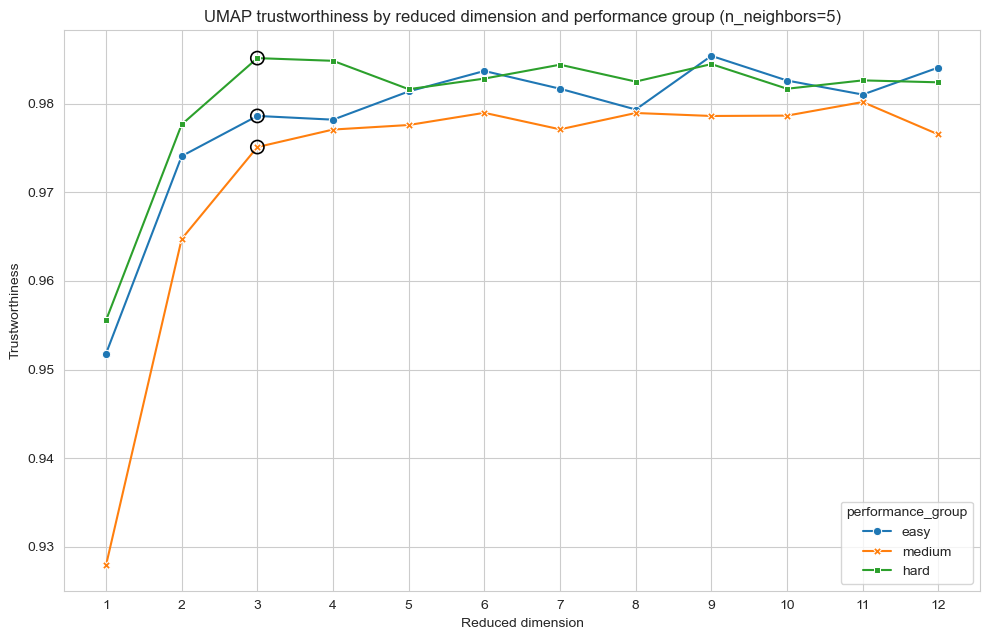

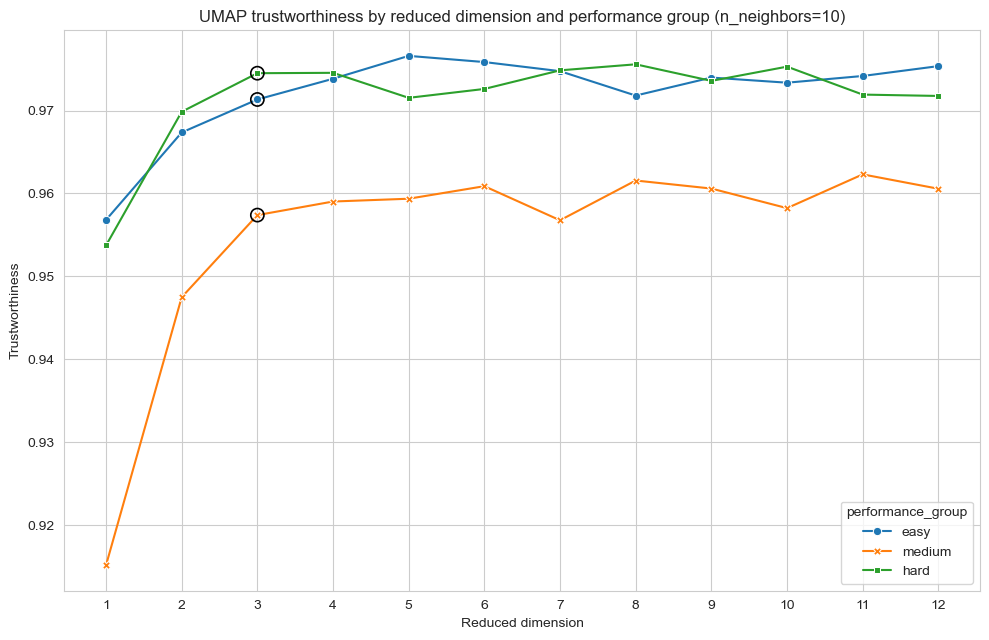

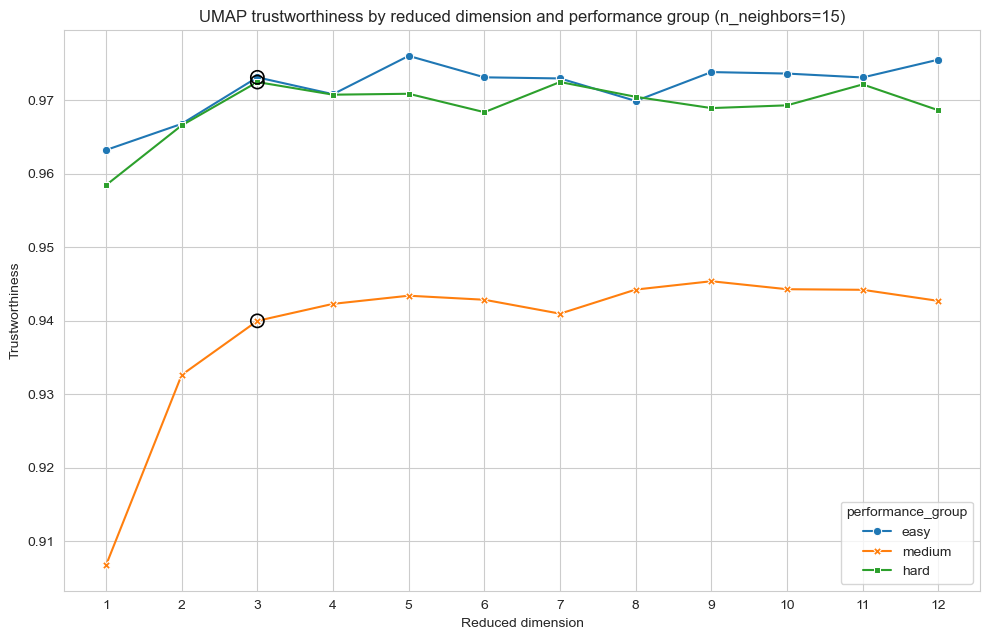

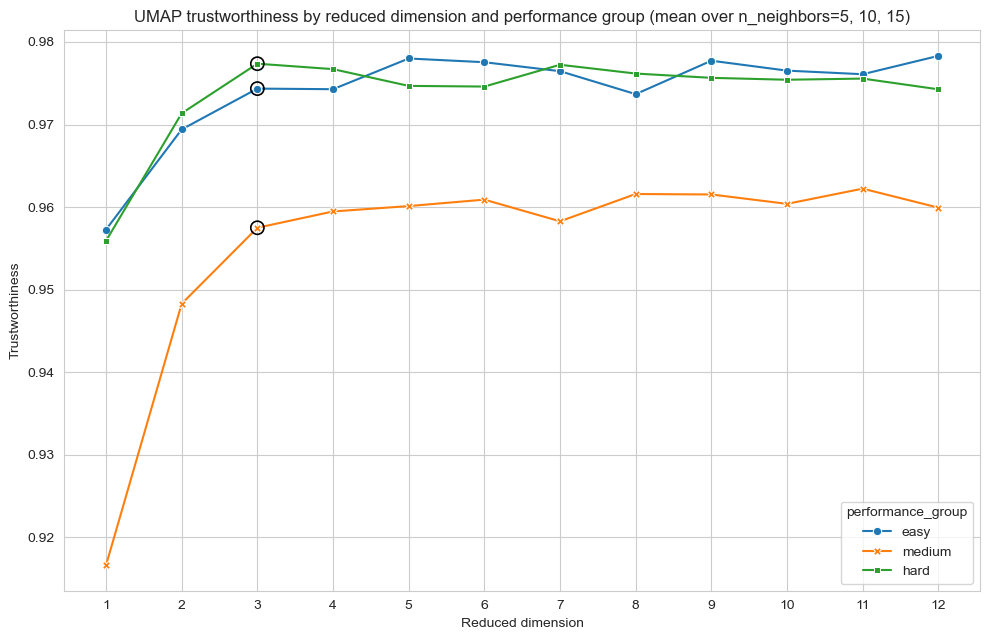

Inspect the trustworthiness curve above, then adjust CLUSTER_SPEC['umap_selected_n_components'] if needed before running the clustering cell below.


,performance_group,n_components,trustworthiness_view,trustworthiness_n_neighbors,trustworthiness,selected_for_clustering
0,easy,1,nn_5,5,0.951791,False
1,easy,1,nn_10,10,0.956814,False
2,easy,1,nn_15,15,0.963232,False
3,easy,1,mean_5_10_15,<NA>,0.957279,False
4,easy,2,nn_5,5,0.974075,False
...,...,...,...,...,...,...
139,hard,11,mean_5_10_15,<NA>,0.975564,False
140,hard,12,nn_5,5,0.982402,False
141,hard,12,nn_10,10,0.971754,False
142,hard,12,nn_15,15,0.968640,False


In [5]:
trustworthiness_df = evaluate_umap_trustworthiness_by_group(
    analysis_df,
    cluster_spec=CLUSTER_SPEC_RESOLVED,
    performance_group_col=PERFORMANCE_GROUP_COL,
    shap_cols=shap_cols,
)

trustworthiness_plot_titles = {
    'nn_5': 'UMAP trustworthiness by reduced dimension and performance group (n_neighbors=5)',
    'nn_10': 'UMAP trustworthiness by reduced dimension and performance group (n_neighbors=10)',
    'nn_15': 'UMAP trustworthiness by reduced dimension and performance group (n_neighbors=15)',
    'mean_5_10_15': 'UMAP trustworthiness by reduced dimension and performance group (mean over n_neighbors=5, 10, 15)',
}

for trustworthiness_view, plot_title in trustworthiness_plot_titles.items():
    plot_df = trustworthiness_df.loc[
        trustworthiness_df['trustworthiness_view'] == trustworthiness_view
    ].copy()
    if plot_df.empty:
        raise ValueError(f'Missing trustworthiness rows for view={trustworthiness_view!r}.')

    fig, ax = plt.subplots(figsize=(10, 6.5))
    sns.lineplot(
        data=plot_df,
        x='n_components',
        y='trustworthiness',
        hue='performance_group',
        style='performance_group',
        markers=True,
        dashes=False,
        ax=ax,
    )
    selected_points_df = plot_df.loc[plot_df['selected_for_clustering']].copy()
    if not selected_points_df.empty:
        ax.scatter(
            selected_points_df['n_components'],
            selected_points_df['trustworthiness'],
            s=90,
            facecolors='none',
            edgecolors='black',
            linewidths=1.2,
            zorder=5,
        )
    ax.set_title(plot_title)
    ax.set_xlabel('Reduced dimension')
    ax.set_ylabel('Trustworthiness')
    ax.set_xticks(sorted(plot_df['n_components'].unique().tolist()))
    plt.tight_layout()
    plt.savefig(UMAP_TRUSTWORTHINESS_PLOT_PATHS[trustworthiness_view], dpi=150, bbox_inches='tight')
    plt.show()

print("Inspect the trustworthiness curve above, then adjust CLUSTER_SPEC['umap_selected_n_components'] if needed before running the clustering cell below.")
display(trustworthiness_df)




## Cluster Within Performance Groups
**Purpose:** Cluster SHAP vectors separately inside each performance group, comparing both algorithms on raw SHAP and the manually selected UMAP latent space when enabled.


In [6]:
clustering_results = run_step2_clustering(
    analysis_df,
    cluster_spec=CLUSTER_SPEC_RESOLVED,
    performance_group_col=PERFORMANCE_GROUP_COL,
    row_id_col='row_id',
    shap_cols=shap_cols,
)

clustered_df = clustering_results['clustered_df']
cluster_scores_df = clustering_results['cluster_scores_df']
best_cluster_runs_df = cluster_scores_df.loc[cluster_scores_df['selected_for_group']].copy()

inspection_algorithm = INSPECTION_CONFIG['inspection_algorithm']
inspection_cluster_space = INSPECTION_CONFIG['inspection_cluster_space']
if inspection_algorithm not in CLUSTER_SPEC_RESOLVED['algorithms']:
    raise ValueError(
        f"Unsupported inspection_algorithm={inspection_algorithm!r}. "
        f"Expected one of {CLUSTER_SPEC_RESOLVED['algorithms']}"
    )
if inspection_cluster_space not in {'raw', 'umap'}:
    raise ValueError(
        f"Unsupported inspection_cluster_space={inspection_cluster_space!r}. Expected 'raw' or 'umap'."
    )
if inspection_cluster_space == 'umap' and not CLUSTER_SPEC_RESOLVED['evaluate_umap_latent_space']:
    raise ValueError("inspection_cluster_space='umap' requires evaluate_umap_latent_space=True.")

inspected_cluster_runs_df = cluster_scores_df.loc[
    (cluster_scores_df['algorithm'] == inspection_algorithm)
    & (cluster_scores_df['cluster_space'] == inspection_cluster_space)
].copy().sort_values('performance_group')
expected_groups = [group for group in CLUSTER_SPEC_RESOLVED['groups'] if group in set(cluster_scores_df['performance_group'])]
missing_groups = [
    group for group in expected_groups
    if group not in set(inspected_cluster_runs_df['performance_group'])
]
if missing_groups:
    raise ValueError(
        'Inspection selection is missing clustering results for performance groups: '
        f'{missing_groups}. selection=({inspection_algorithm}, {inspection_cluster_space})'
    )

cluster_shap_profiles_df = build_cluster_shap_profiles(
    clustered_df,
    inspected_cluster_runs_df,
    performance_group_col=PERFORMANCE_GROUP_COL,
    shap_cols=shap_cols,
)

print(f'Cluster score rows: {len(cluster_scores_df)}')
print(f'Best-ranked regime runs: {len(best_cluster_runs_df)}')
print(
    'Inspection selection: '
    f"algorithm={inspection_algorithm}, cluster_space={inspection_cluster_space}, "
    f"groups={len(inspected_cluster_runs_df)}"
)
print(f'Cluster profile rows: {len(cluster_shap_profiles_df)}')

display(cluster_scores_df)
display(best_cluster_runs_df)
display(inspected_cluster_runs_df)
display(cluster_shap_profiles_df.head())




/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/

Cluster score rows: 12
Best-ranked regime runs: 3
Inspection selection: algorithm=hdbscan, cluster_space=raw, groups=3
Cluster profile rows: 8


,score_row_id,performance_group,algorithm,cluster_space,candidate_label_col,input_dim,group_size,min_cluster_size,min_samples,optics_xi,...,n_clusters,noise_count,noise_fraction,clustered_fraction,dbcv,dbcv_cluster_space,dbcv_raw_shap_space,valid_for_selection,valid_for_raw_shap_evaluation,selected_for_group
2,2,easy,hdbscan,umap,cluster_hdbscan_umap,3,113,5,5,NaN,...,3,0,0.000000,1.000000,0.742153,0.742153,-0.046095,True,True,True
3,3,easy,optics,umap,cluster_optics_umap,3,113,5,5,0.05,...,10,46,0.407080,0.592920,0.343378,0.343378,0.132458,True,True,False
0,0,easy,hdbscan,raw,cluster_hdbscan_raw,13,113,5,5,NaN,...,2,3,0.026549,0.973451,0.336254,0.336254,0.336254,True,True,False
1,1,easy,optics,raw,cluster_optics_raw,13,113,5,5,0.05,...,6,66,0.584071,0.415929,0.119600,0.119600,0.119600,True,True,False
10,10,hard,hdbscan,umap,cluster_hdbscan_umap,3,113,5,5,NaN,...,2,0,0.000000,1.000000,0.877322,0.877322,0.081726,True,True,True
11,11,hard,optics,umap,cluster_optics_umap,3,113,5,5,0.05,...,11,32,0.283186,0.716814,0.387628,0.387628,0.143106,True,True,False
9,9,hard,optics,raw,cluster_optics_raw,13,113,5,5,0.05,...,8,62,0.548673,0.451327,0.196297,0.196297,0.196297,True,True,False
8,8,hard,hdbscan,raw,cluster_hdbscan_raw,13,113,5,5,NaN,...,4,31,0.274336,0.725664,0.181171,0.181171,0.181171,True,True,False
7,7,medium,optics,umap,cluster_optics_umap,3,225,5,5,0.05,...,20,49,0.217778,0.782222,0.336255,0.336255,0.013483,True,True,True
6,6,medium,hdbscan,umap,cluster_hdbscan_umap,3,225,5,5,NaN,...,10,30,0.133333,0.866667,0.336148,0.336148,-0.093443,True,True,False


,score_row_id,performance_group,algorithm,cluster_space,candidate_label_col,input_dim,group_size,min_cluster_size,min_samples,optics_xi,...,n_clusters,noise_count,noise_fraction,clustered_fraction,dbcv,dbcv_cluster_space,dbcv_raw_shap_space,valid_for_selection,valid_for_raw_shap_evaluation,selected_for_group
2,2,easy,hdbscan,umap,cluster_hdbscan_umap,3,113,5,5,NaN,...,3,0,0.000000,1.000000,0.742153,0.742153,-0.046095,True,True,True
10,10,hard,hdbscan,umap,cluster_hdbscan_umap,3,113,5,5,NaN,...,2,0,0.000000,1.000000,0.877322,0.877322,0.081726,True,True,True
7,7,medium,optics,umap,cluster_optics_umap,3,225,5,5,0.05,...,20,49,0.217778,0.782222,0.336255,0.336255,0.013483,True,True,True


,score_row_id,performance_group,algorithm,cluster_space,candidate_label_col,input_dim,group_size,min_cluster_size,min_samples,optics_xi,...,n_clusters,noise_count,noise_fraction,clustered_fraction,dbcv,dbcv_cluster_space,dbcv_raw_shap_space,valid_for_selection,valid_for_raw_shap_evaluation,selected_for_group
0,0,easy,hdbscan,raw,cluster_hdbscan_raw,13,113,5,5,NaN,...,2,3,0.026549,0.973451,0.336254,0.336254,0.336254,True,True,False
8,8,hard,hdbscan,raw,cluster_hdbscan_raw,13,113,5,5,NaN,...,4,31,0.274336,0.725664,0.181171,0.181171,0.181171,True,True,False
4,4,medium,hdbscan,raw,cluster_hdbscan_raw,13,225,5,5,NaN,...,2,51,0.226667,0.773333,0.029007,0.029007,0.029007,True,True,False


,performance_group,selected_algorithm,selected_cluster_space,cluster_id,cluster_size,cluster_size_share,shap__max_speed,shap__std_speed,shap__mean_acceleration,shap__mean_jerk,...,cluster_rank_by_size,dominant_feature_1,dominant_abs_shap_1,dominant_direction_1,dominant_feature_2,dominant_abs_shap_2,dominant_direction_2,dominant_feature_3,dominant_abs_shap_3,dominant_direction_3
0,easy,hdbscan,raw,1,62,0.548673,-0.232887,-0.105563,-0.001769,-0.010578,...,1,max_speed,0.232887,negative,std_speed,0.105563,negative,scene_spatial_density,0.040771,negative
1,easy,hdbscan,raw,0,48,0.424779,0.017895,-0.079982,-0.021311,-0.041925,...,2,heading_change,0.093504,negative,std_speed,0.079982,negative,mean_jerk,0.041925,negative
2,hard,hdbscan,raw,1,34,0.300885,0.108240,-0.028998,0.043583,0.036348,...,1,max_speed,0.108240,positive,min_neighbor_distance,0.047354,positive,mean_acceleration,0.043583,positive
3,hard,hdbscan,raw,3,32,0.283186,0.091921,0.081644,0.021878,0.000724,...,2,heading_change,0.152190,positive,max_speed,0.091921,positive,std_speed,0.081644,positive
4,hard,hdbscan,raw,0,10,0.088496,0.081132,0.297476,-0.060394,0.077237,...,3,std_speed,0.297476,positive,heading_change,0.139066,positive,max_speed,0.081132,positive


## Compare Clustering Outputs
**Purpose:** Show one panel per `(performance group, clustering algorithm)` combination for raw SHAP and reduced SHAP spaces.


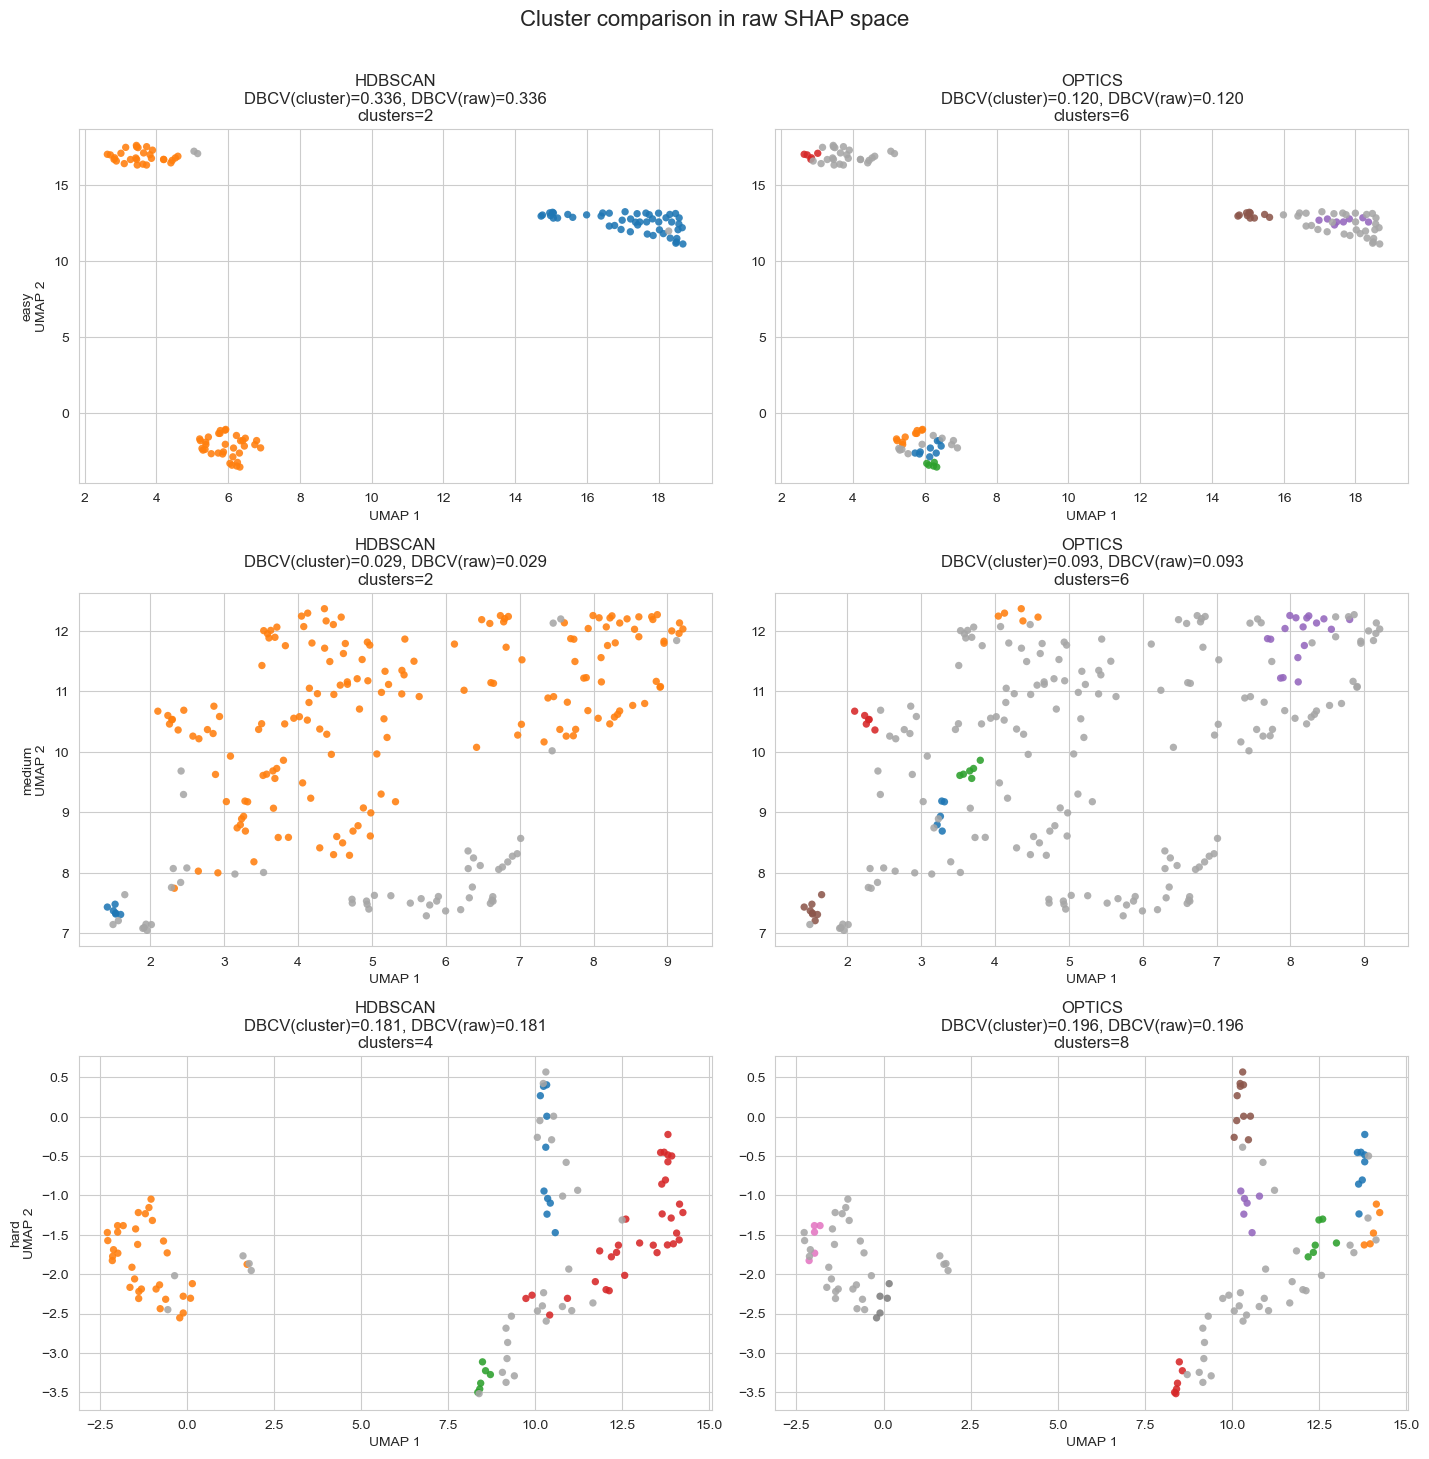

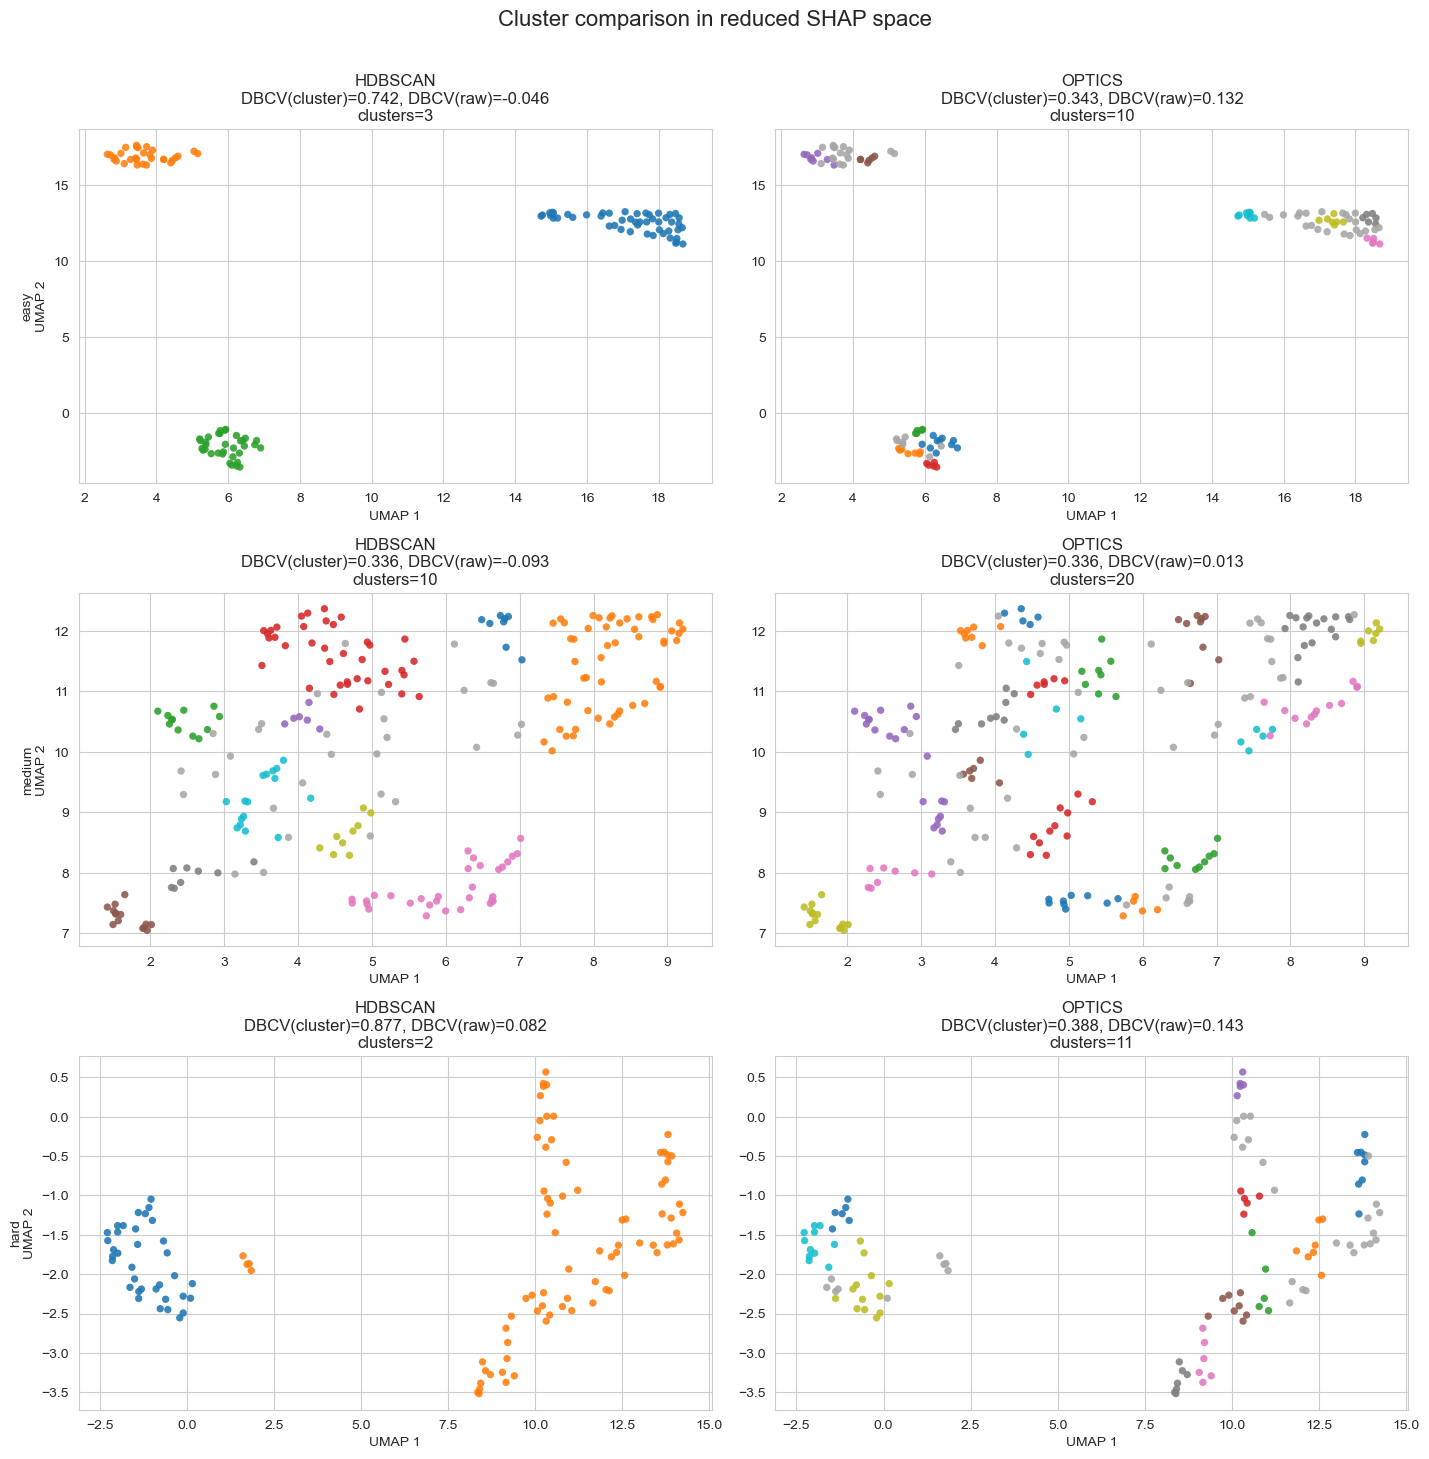

Raw-space clustering runs:


,performance_group,algorithm,cluster_space,dbcv_cluster_space,dbcv_raw_shap_space,n_clusters,noise_fraction
0,easy,hdbscan,raw,0.336254,0.336254,2,0.026549
1,easy,optics,raw,0.119600,0.119600,6,0.584071
2,hard,hdbscan,raw,0.181171,0.181171,4,0.274336
3,hard,optics,raw,0.196297,0.196297,8,0.548673
4,medium,hdbscan,raw,0.029007,0.029007,2,0.226667
5,medium,optics,raw,0.092911,0.092911,6,0.791111


Reduced-space clustering runs:


,performance_group,algorithm,cluster_space,dbcv_cluster_space,dbcv_raw_shap_space,n_clusters,noise_fraction
0,easy,hdbscan,umap,0.742153,-0.046095,3,0.000000
1,easy,optics,umap,0.343378,0.132458,10,0.407080
2,hard,hdbscan,umap,0.877322,0.081726,2,0.000000
3,hard,optics,umap,0.387628,0.143106,11,0.283186
4,medium,hdbscan,umap,0.336148,-0.093443,10,0.133333
5,medium,optics,umap,0.336255,0.013483,20,0.217778


In [7]:
def plot_cluster_comparison_grid(cluster_scores_subset: pd.DataFrame, plot_path: Path, cluster_space_label: str) -> pd.DataFrame:
    groups = CLUSTER_SPEC_RESOLVED['groups']
    algorithms = CLUSTER_SPEC_RESOLVED['algorithms']
    comparison_df = cluster_scores_subset.copy()
    fig, axes = plt.subplots(len(groups), len(algorithms), figsize=(7.2 * len(algorithms), 4.8 * len(groups)), squeeze=False)

    for row_idx, performance_group in enumerate(groups):
        for col_idx, algorithm in enumerate(algorithms):
            ax = axes[row_idx][col_idx]
            selected_rows = comparison_df.loc[
                (comparison_df['performance_group'] == performance_group)
                & (comparison_df['algorithm'] == algorithm)
            ]
            if selected_rows.empty:
                ax.set_visible(False)
                continue

            comparison_row = selected_rows.iloc[0]
            group_df = clustered_df.loc[clustered_df[PERFORMANCE_GROUP_COL] == performance_group].copy()
            label_col = comparison_row['candidate_label_col']
            cluster_ids = [
                int(cluster_id)
                for cluster_id in group_df[label_col].dropna().astype(int).unique().tolist()
            ]
            ordered_cluster_ids = sorted(cluster_id for cluster_id in cluster_ids if cluster_id != -1)
            if -1 in cluster_ids:
                ordered_cluster_ids.append(-1)

            palette = sns.color_palette('tab10', n_colors=max(len(ordered_cluster_ids) - (1 if -1 in ordered_cluster_ids else 0), 1))
            color_lookup = {
                cluster_id: palette[idx % len(palette)]
                for idx, cluster_id in enumerate(cluster_id for cluster_id in ordered_cluster_ids if cluster_id != -1)
            }
            if -1 in ordered_cluster_ids:
                color_lookup[-1] = (0.65, 0.65, 0.65)

            for cluster_id in ordered_cluster_ids:
                cluster_rows = group_df.loc[group_df[label_col].astype('Int64') == cluster_id]
                ax.scatter(
                    cluster_rows['viz_umap_x'],
                    cluster_rows['viz_umap_y'],
                    s=28,
                    alpha=0.88,
                    c=[color_lookup[cluster_id]],
                    edgecolors='none',
                )

            dbcv_cluster_space = comparison_row['dbcv_cluster_space']
            dbcv_cluster_label = f"{dbcv_cluster_space:.3f}" if pd.notna(dbcv_cluster_space) else 'NaN'
            panel_title = f"{algorithm.upper()}\nDBCV={dbcv_cluster_label}, clusters={int(comparison_row['n_clusters'])}"
            ax.set_title(panel_title)
            ax.set_xlabel('UMAP 1')
            if col_idx == 0:
                ax.set_ylabel(f'{performance_group}\nUMAP 2')
            else:
                ax.set_ylabel('')

    fig.suptitle(f'Cluster comparison in {cluster_space_label} space', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    return comparison_df

raw_comparison_df = cluster_scores_df.loc[cluster_scores_df['cluster_space'] == 'raw'].copy()
umap_comparison_df = cluster_scores_df.loc[cluster_scores_df['cluster_space'] == 'umap'].copy()

raw_comparison_df = raw_comparison_df.sort_values(['performance_group', 'algorithm']).reset_index(drop=True)
umap_comparison_df = umap_comparison_df.sort_values(['performance_group', 'algorithm']).reset_index(drop=True)

plot_cluster_comparison_grid(raw_comparison_df, RAW_ALGORITHM_GRID_PATH, 'raw SHAP')
if umap_comparison_df.empty:
    raise ValueError('Reduced-space clustering results are not available. Enable evaluate_umap_latent_space to render the reduced-space comparison grid.')
plot_cluster_comparison_grid(umap_comparison_df, UMAP_ALGORITHM_GRID_PATH, 'reduced SHAP')

print('Raw-space clustering runs:')
display(raw_comparison_df[['performance_group', 'algorithm', 'cluster_space', 'dbcv_raw_shap_space', 'n_clusters', 'noise_fraction']])
print('Reduced-space clustering runs:')
display(umap_comparison_df[['performance_group', 'algorithm', 'cluster_space', 'dbcv_raw_shap_space', 'n_clusters', 'noise_fraction']])



## Inspect Regime SHAP Signatures
**Purpose:** Inspect the user-selected clustering variant for each performance group with compact top-driver tables, signed SHAP bar plots, and full cluster-profile heatmaps.


Inspection profile: easy


,performance_group,inspection_algorithm,inspection_cluster_space,dbcv_cluster_space,dbcv_raw_shap_space,noise_fraction,n_clusters
0,easy,hdbscan,raw,0.336254,0.336254,0.026549,2


,cluster_id,cluster_size,cluster_size_share,dominant_feature_1,dominant_direction_1,dominant_abs_shap_1,dominant_feature_2,dominant_direction_2,dominant_abs_shap_2,dominant_feature_3,dominant_direction_3,dominant_abs_shap_3
0,1,62,0.5487,max_speed,negative,0.2329,std_speed,negative,0.1056,scene_spatial_density,negative,0.0408
1,0,48,0.4248,heading_change,negative,0.0935,std_speed,negative,0.0800,mean_jerk,negative,0.0419


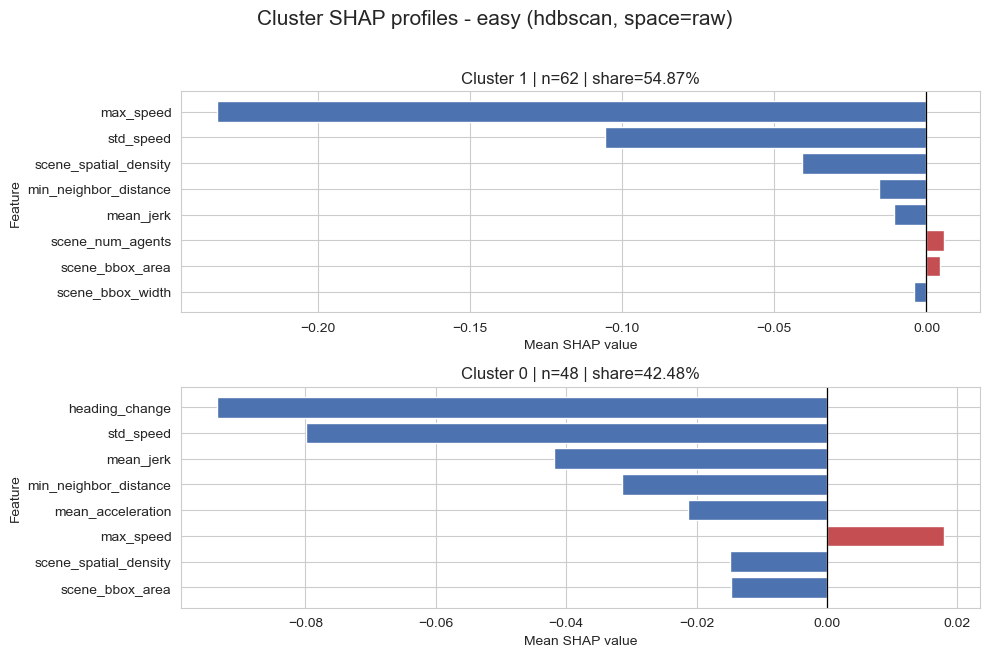

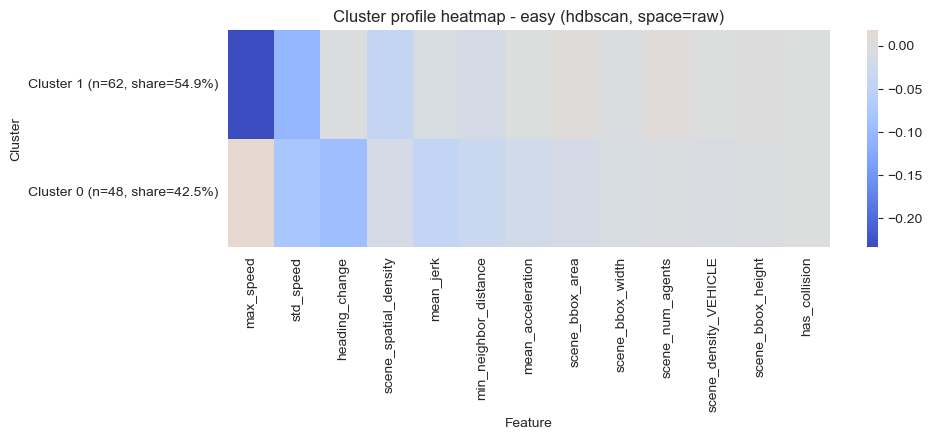

Inspection profile: hard


,performance_group,inspection_algorithm,inspection_cluster_space,dbcv_cluster_space,dbcv_raw_shap_space,noise_fraction,n_clusters
0,hard,hdbscan,raw,0.181171,0.181171,0.274336,4


,cluster_id,cluster_size,cluster_size_share,dominant_feature_1,dominant_direction_1,dominant_abs_shap_1,dominant_feature_2,dominant_direction_2,dominant_abs_shap_2,dominant_feature_3,dominant_direction_3,dominant_abs_shap_3
0,1,34,0.3009,max_speed,positive,0.1082,min_neighbor_distance,positive,0.0474,mean_acceleration,positive,0.0436
1,3,32,0.2832,heading_change,positive,0.1522,max_speed,positive,0.0919,std_speed,positive,0.0816
2,0,10,0.0885,std_speed,positive,0.2975,heading_change,positive,0.1391,max_speed,positive,0.0811
3,2,6,0.0531,std_speed,positive,0.1394,heading_change,positive,0.0950,scene_spatial_density,negative,0.0603


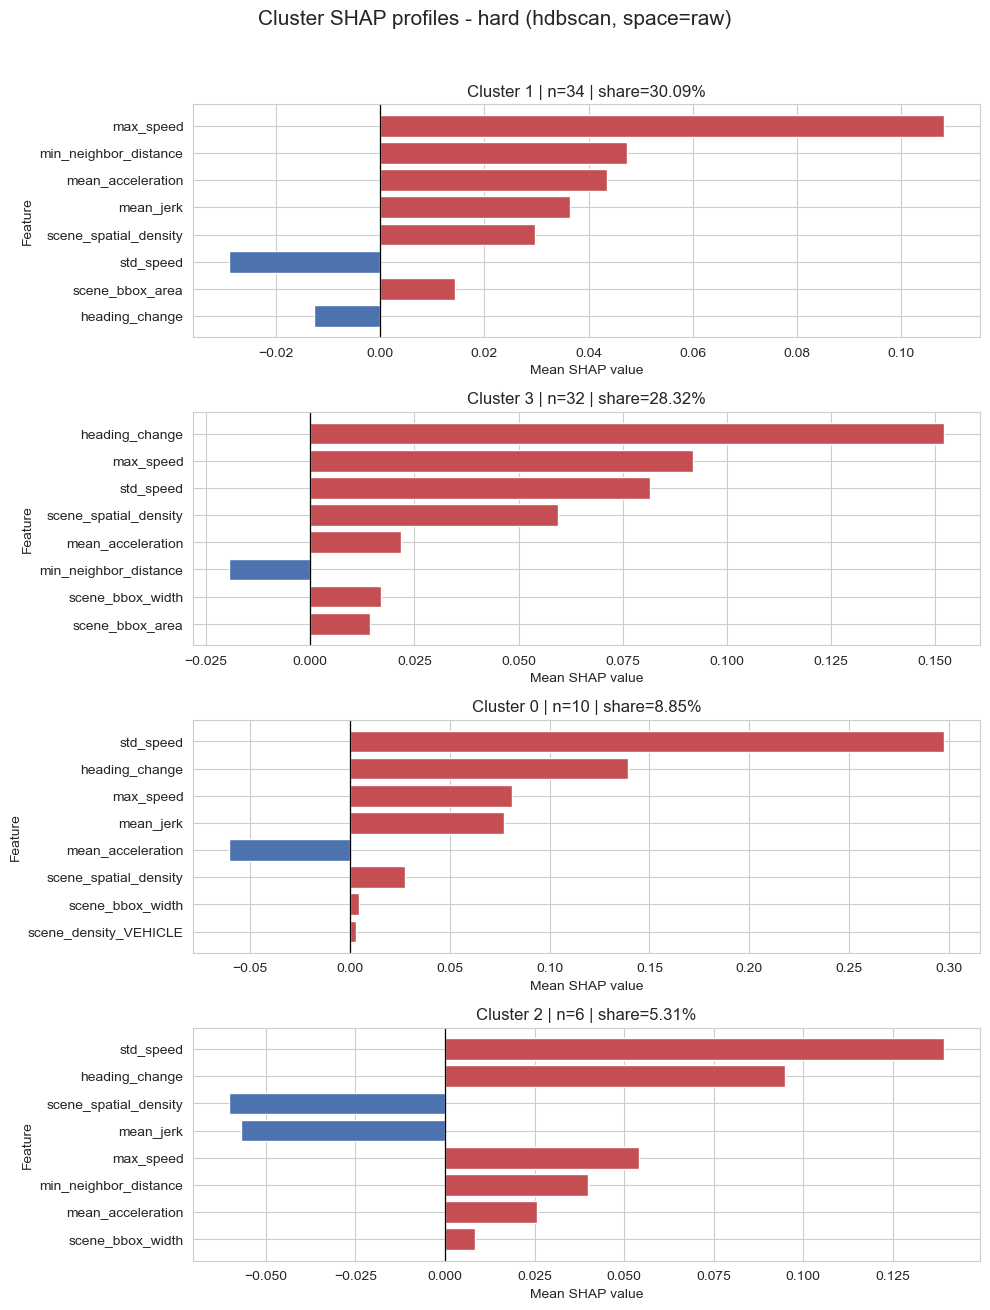

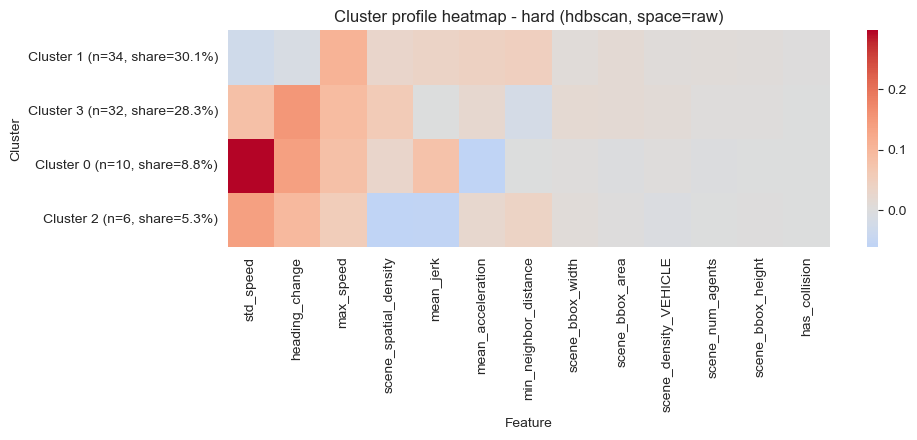

Inspection profile: medium


,performance_group,inspection_algorithm,inspection_cluster_space,dbcv_cluster_space,dbcv_raw_shap_space,noise_fraction,n_clusters
0,medium,hdbscan,raw,0.029007,0.029007,0.226667,2


,cluster_id,cluster_size,cluster_size_share,dominant_feature_1,dominant_direction_1,dominant_abs_shap_1,dominant_feature_2,dominant_direction_2,dominant_abs_shap_2,dominant_feature_3,dominant_direction_3,dominant_abs_shap_3
0,1,168,0.7467,max_speed,positive,0.0643,heading_change,negative,0.0560,std_speed,negative,0.0551
1,0,6,0.0267,max_speed,negative,0.0942,std_speed,negative,0.0748,scene_spatial_density,negative,0.0507


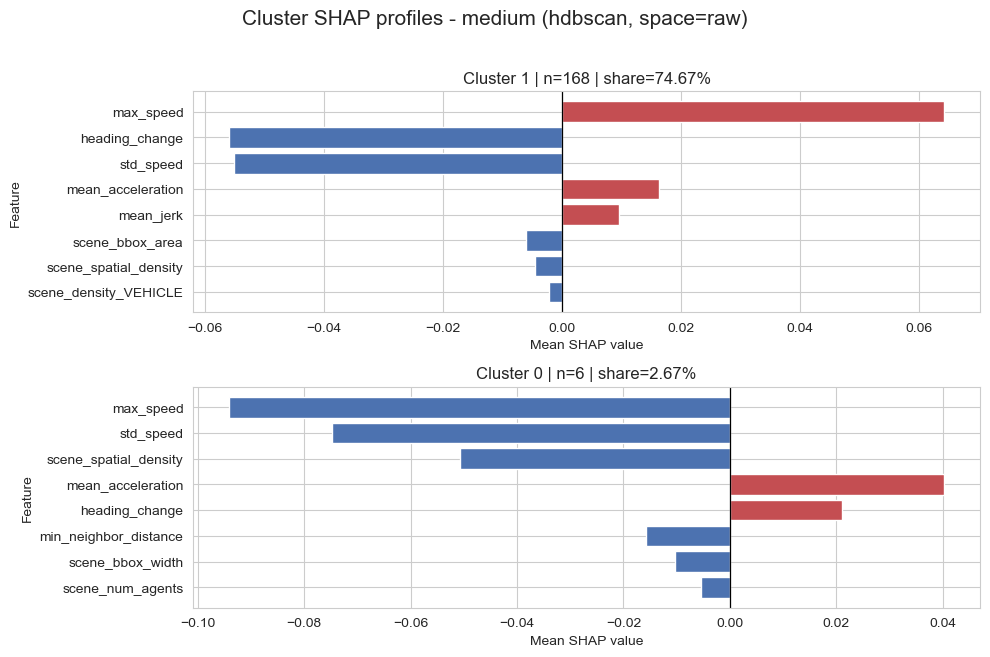

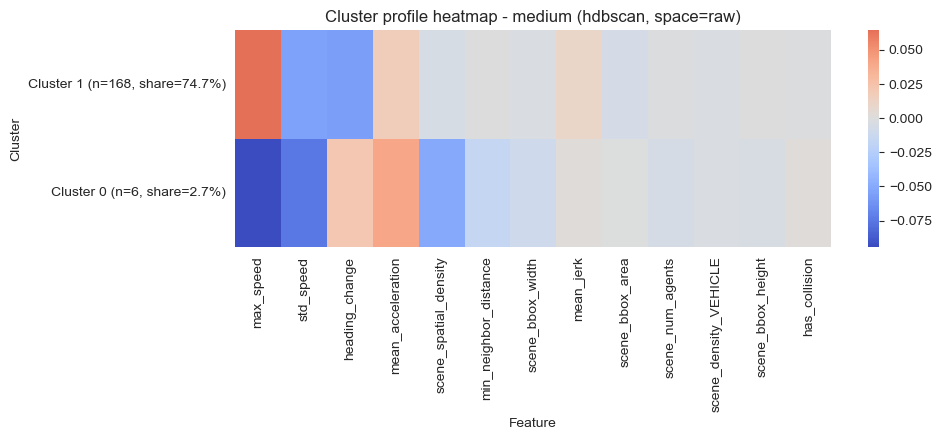

,performance_group,inspection_algorithm,inspection_cluster_space,barplot_plot_path
0,easy,hdbscan,raw,../../results/interpretable_model/shap_perform...
1,hard,hdbscan,raw,../../results/interpretable_model/shap_perform...
2,medium,hdbscan,raw,../../results/interpretable_model/shap_perform...


,performance_group,inspection_algorithm,inspection_cluster_space,heatmap_plot_path
0,easy,hdbscan,raw,../../results/interpretable_model/shap_perform...
1,hard,hdbscan,raw,../../results/interpretable_model/shap_perform...
2,medium,hdbscan,raw,../../results/interpretable_model/shap_perform...


In [8]:
barplot_manifest_records = []
heatmap_manifest_records = []

sort_key = INSPECTION_CONFIG['sort_cluster_profiles_by']
if sort_key not in {'cluster_size', 'cluster_rank_by_size'}:
    raise ValueError(f'Unsupported sort_cluster_profiles_by value: {sort_key}')

for _, inspected_run in inspected_cluster_runs_df.sort_values('performance_group').iterrows():
    performance_group = inspected_run['performance_group']
    profile_df = cluster_shap_profiles_df.loc[
        cluster_shap_profiles_df['performance_group'] == performance_group
    ].copy()
    if profile_df.empty:
        continue

    ascending_flags = [False, True] if sort_key == 'cluster_size' else [True, True]
    profile_df = profile_df.sort_values([sort_key, 'cluster_id'], ascending=ascending_flags).reset_index(drop=True)
    ordered_shap_cols = (
        profile_df[shap_cols]
        .abs()
        .mean(axis=0)
        .sort_values(ascending=False)
        .index
        .tolist()
    )
    feature_label_lookup = {shap_col: format_shap_feature_name(shap_col) for shap_col in shap_cols}

    metadata_df = pd.DataFrame(
        [
            {
                'performance_group': performance_group,
                'inspection_algorithm': inspected_run['algorithm'],
                'inspection_cluster_space': inspected_run['cluster_space'],
                'dbcv_raw_shap_space': inspected_run['dbcv_raw_shap_space'],
                'noise_fraction': inspected_run['noise_fraction'],
                'n_clusters': inspected_run['n_clusters'],
            }
        ]
    )
    print(f'Inspection profile: {performance_group}')
    display(metadata_df)

    top_driver_columns = ['cluster_id', 'cluster_size', 'cluster_size_share']
    for rank in range(1, INSPECTION_CONFIG['inspection_top_k_table'] + 1):
        top_driver_columns.extend([
            f'dominant_feature_{rank}',
            f'dominant_direction_{rank}',
            f'dominant_abs_shap_{rank}',
        ])
    top_driver_df = profile_df[top_driver_columns].copy()
    top_driver_df['cluster_size_share'] = top_driver_df['cluster_size_share'].round(4)
    for rank in range(1, INSPECTION_CONFIG['inspection_top_k_table'] + 1):
        top_driver_df[f'dominant_abs_shap_{rank}'] = top_driver_df[f'dominant_abs_shap_{rank}'].round(4)
    display(top_driver_df)

    n_clusters = len(profile_df)
    fig, axes = plt.subplots(n_clusters, 1, figsize=(10, max(3.2 * n_clusters, 4.5)), squeeze=False)
    for axis_idx, (_, cluster_row) in enumerate(profile_df.iterrows()):
        ax = axes[axis_idx][0]
        top_shap_cols = sorted(
            shap_cols,
            key=lambda shap_col: abs(float(cluster_row[shap_col])),
            reverse=True,
        )[: INSPECTION_CONFIG['inspection_top_k_features']]
        top_shap_cols = list(reversed(top_shap_cols))
        values = [float(cluster_row[shap_col]) for shap_col in top_shap_cols]
        labels = [feature_label_lookup[shap_col] for shap_col in top_shap_cols]
        colors = ['#C44E52' if value > 0 else '#4C72B0' for value in values]
        ax.barh(labels, values, color=colors)
        ax.axvline(0, color='black', linewidth=0.9)
        ax.set_title(
            f"Cluster {int(cluster_row['cluster_id'])} | n={int(cluster_row['cluster_size'])} | share={cluster_row['cluster_size_share']:.2%}"
        )
        ax.set_xlabel('Mean SHAP value')
        ax.set_ylabel('Feature')
    fig.suptitle(
        f"Cluster SHAP profiles - {performance_group} ({inspected_run['algorithm']}, space={inspected_run['cluster_space']})",
        fontsize=15,
        y=1.02,
    )
    plt.tight_layout()
    barplot_path = PLOTS_DIR / f'inspected_cluster_profile_barplot_{performance_group}_{target_col}.png'
    plt.savefig(barplot_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    heatmap_index = [
        f"Cluster {int(cluster_id)} (n={int(cluster_size)}, share={cluster_share:.1%})"
        for cluster_id, cluster_size, cluster_share in zip(
            profile_df['cluster_id'],
            profile_df['cluster_size'],
            profile_df['cluster_size_share'],
        )
    ]
    heatmap_plot_df = profile_df[ordered_shap_cols].copy()
    heatmap_plot_df.columns = [feature_label_lookup[shap_col] for shap_col in ordered_shap_cols]
    heatmap_plot_df.index = pd.Index(heatmap_index)
    heatmap_path = PLOTS_DIR / f'inspected_cluster_profile_heatmap_{performance_group}_{target_col}.png'

    fig, ax = plt.subplots(figsize=(max(10, len(ordered_shap_cols) * 0.55), max(4.5, len(profile_df) * 0.9)))
    sns.heatmap(
        heatmap_plot_df,
        cmap='coolwarm',
        center=0,
        ax=ax,
    )
    ax.set_title(
        f"Cluster profile heatmap - {performance_group} ({inspected_run['algorithm']}, space={inspected_run['cluster_space']})"
    )
    ax.set_xlabel('Feature')
    ax.set_ylabel('Cluster')
    plt.tight_layout()
    plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    barplot_manifest_records.append(
        {
            'performance_group': performance_group,
            'inspection_algorithm': inspected_run['algorithm'],
            'inspection_cluster_space': inspected_run['cluster_space'],
            'barplot_plot_path': str(barplot_path),
        }
    )
    heatmap_manifest_records.append(
        {
            'performance_group': performance_group,
            'inspection_algorithm': inspected_run['algorithm'],
            'inspection_cluster_space': inspected_run['cluster_space'],
            'heatmap_plot_path': str(heatmap_path),
        }
    )

barplot_manifest_df = pd.DataFrame(barplot_manifest_records)
heatmap_manifest_df = pd.DataFrame(heatmap_manifest_records)
display(barplot_manifest_df)
display(heatmap_manifest_df)



## Export Regime Artifacts
**Purpose:** Persist the assembled regime table, clustering outputs, and selected cluster-profile plots for downstream interpretation.


In [9]:
analysis_df.to_csv(REGIME_ANALYSIS_PATH, index=False)
group_summary_df.to_csv(PERFORMANCE_GROUP_SUMMARY_PATH, index=False)
trustworthiness_df.to_csv(UMAP_TRUSTWORTHINESS_PATH, index=False)
cluster_scores_df.to_csv(CLUSTER_SCORES_PATH, index=False)
clustered_df.to_csv(CLUSTER_ASSIGNMENTS_PATH, index=False)
cluster_shap_profiles_df.to_csv(CLUSTER_SHAP_PROFILES_PATH, index=False)

trustworthiness_plot_manifest_df = pd.DataFrame(
    [
        {
            'plot_type': 'umap_trustworthiness_curve',
            'trustworthiness_view': trustworthiness_view,
            'path': str(plot_path),
        }
        for trustworthiness_view, plot_path in UMAP_TRUSTWORTHINESS_PLOT_PATHS.items()
    ]
)

plot_manifest_df = pd.concat(
    [
        trustworthiness_plot_manifest_df,
        pd.DataFrame(
            [
                {'plot_type': 'raw_algorithm_comparison_grid', 'path': str(RAW_ALGORITHM_GRID_PATH)},
                {'plot_type': 'umap_algorithm_comparison_grid', 'path': str(UMAP_ALGORITHM_GRID_PATH)},
            ]
        ),
        barplot_manifest_df.rename(columns={'barplot_plot_path': 'path'}).assign(plot_type='inspected_cluster_profile_barplot')[['plot_type', 'performance_group', 'path']],
        heatmap_manifest_df.rename(columns={'heatmap_plot_path': 'path'}).assign(plot_type='inspected_cluster_profile_heatmap')[['plot_type', 'performance_group', 'path']],
    ],
    ignore_index=True,
    sort=False,
)

print('Saved artifacts:')
print(f'- Run manifest:               {run_ctx.manifest_path}')
print(f'- Prepared data export:       {PREPARED_DATA_PATH}')
print(f'- SHAP value export:          {SHAP_VALUES_PATH}')
print(f'- Joined metrics export:      {JOINED_METRICS_PATH}')
print(f'- Regime analysis table:      {REGIME_ANALYSIS_PATH}')
print(f'- Performance group summary:  {PERFORMANCE_GROUP_SUMMARY_PATH}')
print(f'- UMAP trustworthiness:       {UMAP_TRUSTWORTHINESS_PATH}')
for trustworthiness_view, plot_path in UMAP_TRUSTWORTHINESS_PLOT_PATHS.items():
    print(f'- Trustworthiness curve ({trustworthiness_view}): {plot_path}')
print(f'- Cluster scores:             {CLUSTER_SCORES_PATH}')
print(f'- Cluster assignments:        {CLUSTER_ASSIGNMENTS_PATH}')
print(f'- Cluster SHAP profiles:      {CLUSTER_SHAP_PROFILES_PATH}')
print(
    '- Inspection selection:      '
    f"algorithm={INSPECTION_CONFIG['inspection_algorithm']}, "
    f"space={INSPECTION_CONFIG['inspection_cluster_space']}"
)
print(f'- Raw comparison grid:        {RAW_ALGORITHM_GRID_PATH}')
print(f'- Reduced comparison grid:    {UMAP_ALGORITHM_GRID_PATH}')
print(f'- Plot directory:             {PLOTS_DIR}')

display(plot_manifest_df)



Saved artifacts:
- Run manifest:               /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/xgboost/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/run_manifest_ml_ade_log.json
- Prepared data export:       ../../results/interpretable_model/prepared_data/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/prepared_data_ml_ade.csv
- SHAP value export:          /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/xgboost/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/shap_values_ml_ade_log.csv
- Joined metrics export:      ../../results/trajectory_prediction/trajectory_metrics_joined/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/eval_epoch_5.csv
- Regime analysis table:      ../../results/interpretable_model/shap_performance_regimes/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/regime_analysis_ml_ade_log.csv
- Performance group summary:  ../../results/interpretable_model/shap_performance_regimes/nusc_mini_debug_tpp-11_Mar

,plot_type,trustworthiness_view,path,performance_group
0,umap_trustworthiness_curve,nn_5,../../results/interpretable_model/shap_perform...,NaN
1,umap_trustworthiness_curve,nn_10,../../results/interpretable_model/shap_perform...,NaN
2,umap_trustworthiness_curve,nn_15,../../results/interpretable_model/shap_perform...,NaN
3,umap_trustworthiness_curve,mean_5_10_15,../../results/interpretable_model/shap_perform...,NaN
4,raw_algorithm_comparison_grid,NaN,../../results/interpretable_model/shap_perform...,NaN
5,umap_algorithm_comparison_grid,NaN,../../results/interpretable_model/shap_perform...,NaN
6,inspected_cluster_profile_barplot,NaN,../../results/interpretable_model/shap_perform...,easy
7,inspected_cluster_profile_barplot,NaN,../../results/interpretable_model/shap_perform...,hard
8,inspected_cluster_profile_barplot,NaN,../../results/interpretable_model/shap_perform...,medium
9,inspected_cluster_profile_heatmap,NaN,../../results/interpretable_model/shap_perform...,easy
